# 01 Data Exploration

Week 1 notebook for inspecting the Kaggle P&ID Symbols dataset, verifying split files, converting YOLO annotations to pixel coordinates, and visualizing example tiles.

This notebook matches the current local dataset layout:

- dataset root: `C:/Users/jimmy/Downloads/pidset`
- image directory: `images (3)`
- label directory: `labels (2)`
- split files: `train (2).txt`, `val (1).txt`


In [17]:
from pathlib import Path
import re
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["axes.grid"] = False


In [18]:
DATASET_ROOT = Path(r"C:\Users\jimmy\Downloads\pidset")
IMAGE_DIR = DATASET_ROOT / "images (3)"
LABEL_DIR = DATASET_ROOT / "labels (2)"
TRAIN_SPLIT = DATASET_ROOT / "train (2).txt"
VAL_SPLIT = DATASET_ROOT / "val (1).txt"

for path in [DATASET_ROOT, IMAGE_DIR, LABEL_DIR, TRAIN_SPLIT, VAL_SPLIT]:
    print(path, "->", path.exists())


C:\Users\jimmy\Downloads\pidset -> True
C:\Users\jimmy\Downloads\pidset\images (3) -> True
C:\Users\jimmy\Downloads\pidset\labels (2) -> True
C:\Users\jimmy\Downloads\pidset\train (2).txt -> True
C:\Users\jimmy\Downloads\pidset\val (1).txt -> True


## Helper Functions

In [19]:
def normalize_split_entry(entry: str) -> str:
    entry = entry.strip().replace('\\', '/')
    entry = entry.replace('./images/', '').replace('images/', '')
    return Path(entry).name


def read_split_file(path: Path) -> list[str]:
    return [normalize_split_entry(line) for line in path.read_text().splitlines() if line.strip()]


def image_path_from_name(image_name: str) -> Path:
    return IMAGE_DIR / image_name


def label_path_from_name(image_name: str) -> Path:
    return LABEL_DIR / f"{Path(image_name).stem}.txt"


def parse_tile_name(image_name: str) -> dict:
    stem = Path(image_name).stem
    parts = stem.split('_')
    if len(parts) != 3:
        return {"tile_name": stem, "diagram_id": None, "crop_x": None, "crop_y": None}
    diagram_id, crop_x, crop_y = parts
    return {
        "tile_name": stem,
        "diagram_id": diagram_id,
        "crop_x": int(crop_x),
        "crop_y": int(crop_y),
    }


def load_yolo_annotations(label_path: Path) -> pd.DataFrame:
    if not label_path.exists() or label_path.stat().st_size == 0:
        return pd.DataFrame(columns=["class_id", "x_center", "y_center", "width", "height"])

    df = pd.read_csv(
        label_path,
        sep=r"\s+",
        header=None,
        names=["class_id", "x_center", "y_center", "width", "height"],
    )
    df["class_id"] = df["class_id"].astype(int)
    return df


def yolo_to_pixel_boxes(df: pd.DataFrame, image_width: int, image_height: int) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    pixel_df = df.copy()
    pixel_df["x_center_px"] = pixel_df["x_center"] * image_width
    pixel_df["y_center_px"] = pixel_df["y_center"] * image_height
    pixel_df["width_px"] = pixel_df["width"] * image_width
    pixel_df["height_px"] = pixel_df["height"] * image_height
    pixel_df["x_min"] = pixel_df["x_center_px"] - pixel_df["width_px"] / 2
    pixel_df["y_min"] = pixel_df["y_center_px"] - pixel_df["height_px"] / 2
    pixel_df["x_max"] = pixel_df["x_center_px"] + pixel_df["width_px"] / 2
    pixel_df["y_max"] = pixel_df["y_center_px"] + pixel_df["height_px"] / 2
    return pixel_df


def load_image_rgb(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def draw_boxes(image: np.ndarray, boxes_df: pd.DataFrame, class_name_map: dict[int, str] | None = None) -> np.ndarray:
    canvas = image.copy()
    for _, row in boxes_df.iterrows():
        x_min, y_min, x_max, y_max = map(int, [row.x_min, row.y_min, row.x_max, row.y_max])
        cv2.rectangle(canvas, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
        class_label = class_name_map.get(int(row.class_id), f"class_{int(row.class_id)}") if class_name_map else f"class_{int(row.class_id)}"
        cv2.putText(canvas, class_label, (x_min, max(20, y_min - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    return canvas


def sample_split(split_names: list[str], count: int = 12, seed: int = 7) -> list[str]:
    rng = np.random.default_rng(seed)
    count = min(count, len(split_names))
    indices = rng.choice(len(split_names), size=count, replace=False)
    return [split_names[i] for i in sorted(indices)]


## Split Inspection

In [20]:
train_images = read_split_file(TRAIN_SPLIT)
val_images = read_split_file(VAL_SPLIT)

print(f"train images: {len(train_images):,}")
print(f"val images:   {len(val_images):,}")
print("train sample:", train_images[:5])
print("val sample:", val_images[:5])


train images: 27,000
val images:   3,000
train sample: ['73_1280_1280.jpg', '142_2560_3200.jpg', '311_1920_4480.jpg', '129_3200_1920.jpg', '4_0_640.jpg']
val sample: ['246_2560_0.jpg', '75_1920_2560.jpg', '321_1920_2560.jpg', '307_1920_1280.jpg', '192_1280_4480.jpg']


In [21]:
train_diagram_ids = {parse_tile_name(name)["diagram_id"] for name in train_images}
val_diagram_ids = {parse_tile_name(name)["diagram_id"] for name in val_images}
overlap_diagram_ids = sorted(train_diagram_ids & val_diagram_ids)

print(f"unique train diagram ids: {len(train_diagram_ids):,}")
print(f"unique val diagram ids:   {len(val_diagram_ids):,}")
print(f"overlap diagram ids:      {len(overlap_diagram_ids):,}")
print("first overlap ids:", overlap_diagram_ids[:20])


unique train diagram ids: 500
unique val diagram ids:   498
overlap diagram ids:      498
first overlap ids: ['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115']


## One-Tile Annotation Check

In [22]:
example_image_name = "9_640_640.jpg"
example_image_path = image_path_from_name(example_image_name)
example_label_path = label_path_from_name(example_image_name)

example_image = load_image_rgb(example_image_path)
image_height, image_width = example_image.shape[:2]
example_ann = load_yolo_annotations(example_label_path)
example_boxes = yolo_to_pixel_boxes(example_ann, image_width=image_width, image_height=image_height)

print("image shape:", example_image.shape)
print("annotation count:", len(example_boxes))
example_boxes.head()


image shape: (1280, 1280, 3)
annotation count: 7


,class_id,x_center,y_center,width,height,x_center_px,y_center_px,width_px,height_px,x_min,y_min,x_max,y_max
0,32,0.775391,0.568750,0.099219,0.098437,992.5,728.0,127.0,126.0,929.0,665.0,1056.0,791.0
1,26,0.670703,0.236328,0.097656,0.099219,858.5,302.5,125.0,127.0,796.0,239.0,921.0,366.0
2,22,0.734766,0.123047,0.041406,0.063281,940.5,157.5,53.0,81.0,914.0,117.0,967.0,198.0
3,12,0.126172,0.568750,0.074219,0.048438,161.5,728.0,95.0,62.0,114.0,697.0,209.0,759.0
4,9,0.362109,0.118359,0.075781,0.057031,463.5,151.5,97.0,73.0,415.0,115.0,512.0,188.0


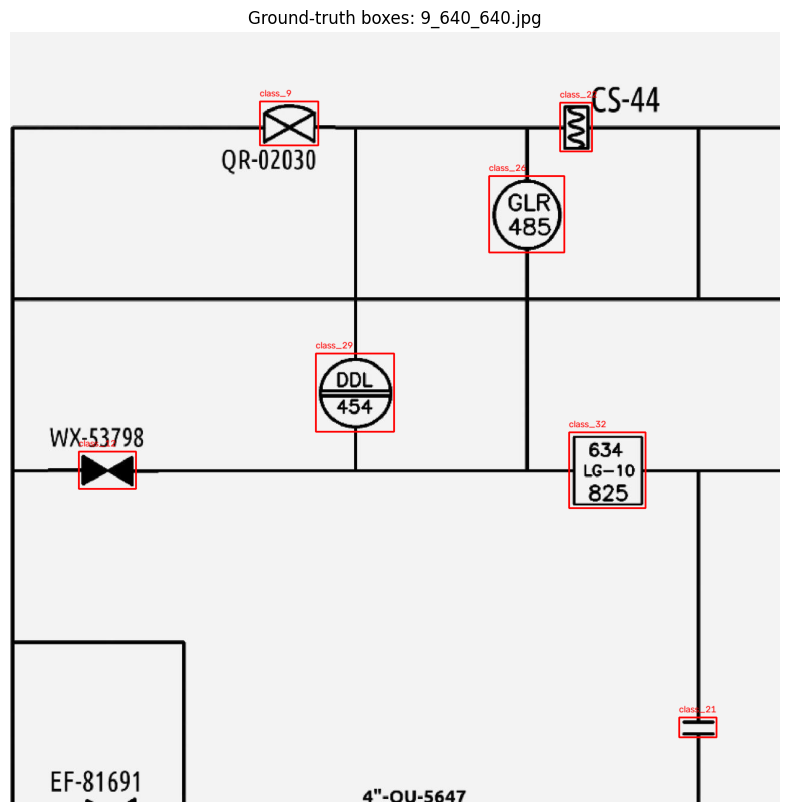

In [23]:
# Replace this mapping once the dataset class list is confirmed.
CLASS_NAME_MAP = {}

overlay = draw_boxes(example_image, example_boxes, class_name_map=CLASS_NAME_MAP)
plt.imshow(overlay)
plt.title(f"Ground-truth boxes: {example_image_name}")
plt.axis("off");


## Dataset Size and Image-Dimension Checks

In [24]:
all_image_names = sorted([path.name for path in IMAGE_DIR.glob('*.jpg')])
all_label_names = sorted([path.name for path in LABEL_DIR.glob('*.txt')])

print(f"all images: {len(all_image_names):,}")
print(f"all labels: {len(all_label_names):,}")
print("missing labels for images:", sum(not label_path_from_name(name).exists() for name in all_image_names))
print("missing images for labels:", sum(not image_path_from_name(name.replace('.txt', '.jpg')).exists() for name in all_label_names))


all images: 30,000
all labels: 30,000
missing labels for images: 0
missing images for labels: 0


In [25]:
dimension_records = []
for image_name in sample_split(all_image_names, count=30, seed=21):
    with Image.open(image_path_from_name(image_name)) as image:
        width, height = image.size
    dimension_records.append({"image_name": image_name, "width": width, "height": height})

dimension_df = pd.DataFrame(dimension_records)
dimension_df.head()


,image_name,width,height
0,13_2560_0.jpg,1280,1280
1,150_1280_0.jpg,1280,1280
2,189_2560_3200.jpg,1280,1280
3,194_3200_3200.jpg,1280,1280
4,209_0_5120.jpg,1280,1280


In [26]:
dimension_df[["width", "height"]].value_counts().rename("count")


width  height
1280   1280      30
Name: count, dtype: int64

## Annotation Statistics

In [35]:
annotation_records = []
for image_name in train_images + val_images:
    label_path = label_path_from_name(image_name)
    ann_df = load_yolo_annotations(label_path)
    tile_info = parse_tile_name(image_name)
    for _, row in ann_df.iterrows():
        annotation_records.append({
            "image_name": image_name,
            "diagram_id": tile_info["diagram_id"],
            "crop_x": tile_info["crop_x"],
            "crop_y": tile_info["crop_y"],
            "class_id": int(row.class_id),
            "width_norm": float(row.width),
            "height_norm": float(row.height),
            "area_norm": float(row.width * row.height),
        })

ann_stats_df = pd.DataFrame(annotation_records)
print(f"total annotations: {len(ann_stats_df):,}")
ann_stats_df.tail(20)


total annotations: 195,264


,image_name,diagram_id,crop_x,crop_y,class_id,width_norm,height_norm,area_norm
195244,230_0_3200.jpg,230,0,3200,4,0.050781,0.032031,0.001627
195245,60_1920_0.jpg,60,1920,0,28,0.089844,0.089844,0.008072
195246,60_1920_0.jpg,60,1920,0,20,0.053906,0.050781,0.002737
195247,60_1920_0.jpg,60,1920,0,23,0.098437,0.053906,0.005306
195248,60_1920_0.jpg,60,1920,0,23,0.056250,0.098437,0.005537
195249,60_1920_0.jpg,60,1920,0,25,0.051562,0.051562,0.002659
195250,1_0_0.jpg,1,0,0,21,0.025000,0.048438,0.001211
195251,1_0_0.jpg,1,0,0,13,0.064844,0.047656,0.003090
195252,1_0_0.jpg,1,0,0,15,0.048438,0.045312,0.002195
195253,1_0_0.jpg,1,0,0,31,0.099219,0.097656,0.009689


In [33]:
class_counts = ann_stats_df["class_id"].value_counts().sort_index()
class_counts.head(20)


class_id
1     5531
2     6044
3     5879
4     5893
5     6109
6     6119
7     5540
8     5751
9     6034
10    5545
11    5877
12    6088
13    5971
14    5509
15    5837
16    6267
17    5756
18    5622
19    5576
20    5837
Name: count, dtype: int64

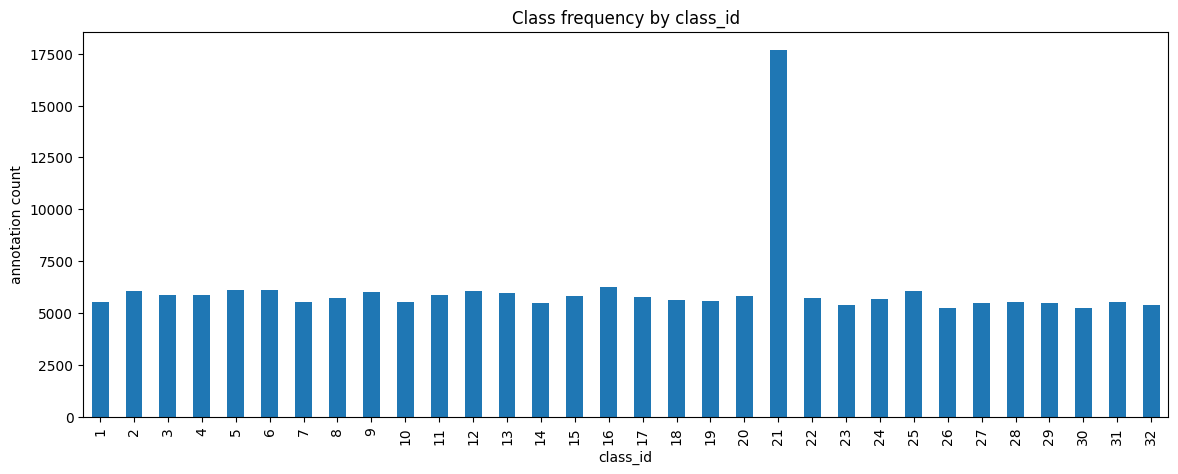

In [29]:
ax = class_counts.plot(kind="bar", figsize=(14, 5), title="Class frequency by class_id")
ax.set_xlabel("class_id")
ax.set_ylabel("annotation count");


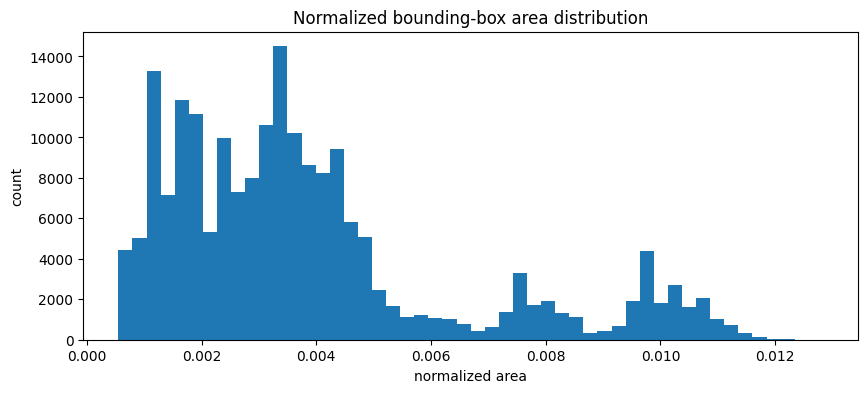

In [30]:
ax = ann_stats_df["area_norm"].plot(kind="hist", bins=50, figsize=(10, 4), title="Normalized bounding-box area distribution")
ax.set_xlabel("normalized area")
ax.set_ylabel("count");


## Visualize a Small Development Subset

In [31]:
development_subset = sample_split(train_images, count=12, seed=42)
development_subset


['81_2560_4480.jpg',
 '380_1280_4480.jpg',
 '50_640_1280.jpg',
 '228_2560_1280.jpg',
 '476_1920_4480.jpg',
 '447_2560_5120.jpg',
 '451_3200_5120.jpg',
 '383_1280_3200.jpg',
 '247_3200_2560.jpg',
 '409_1920_4480.jpg',
 '252_1920_1920.jpg',
 '478_2560_5120.jpg']

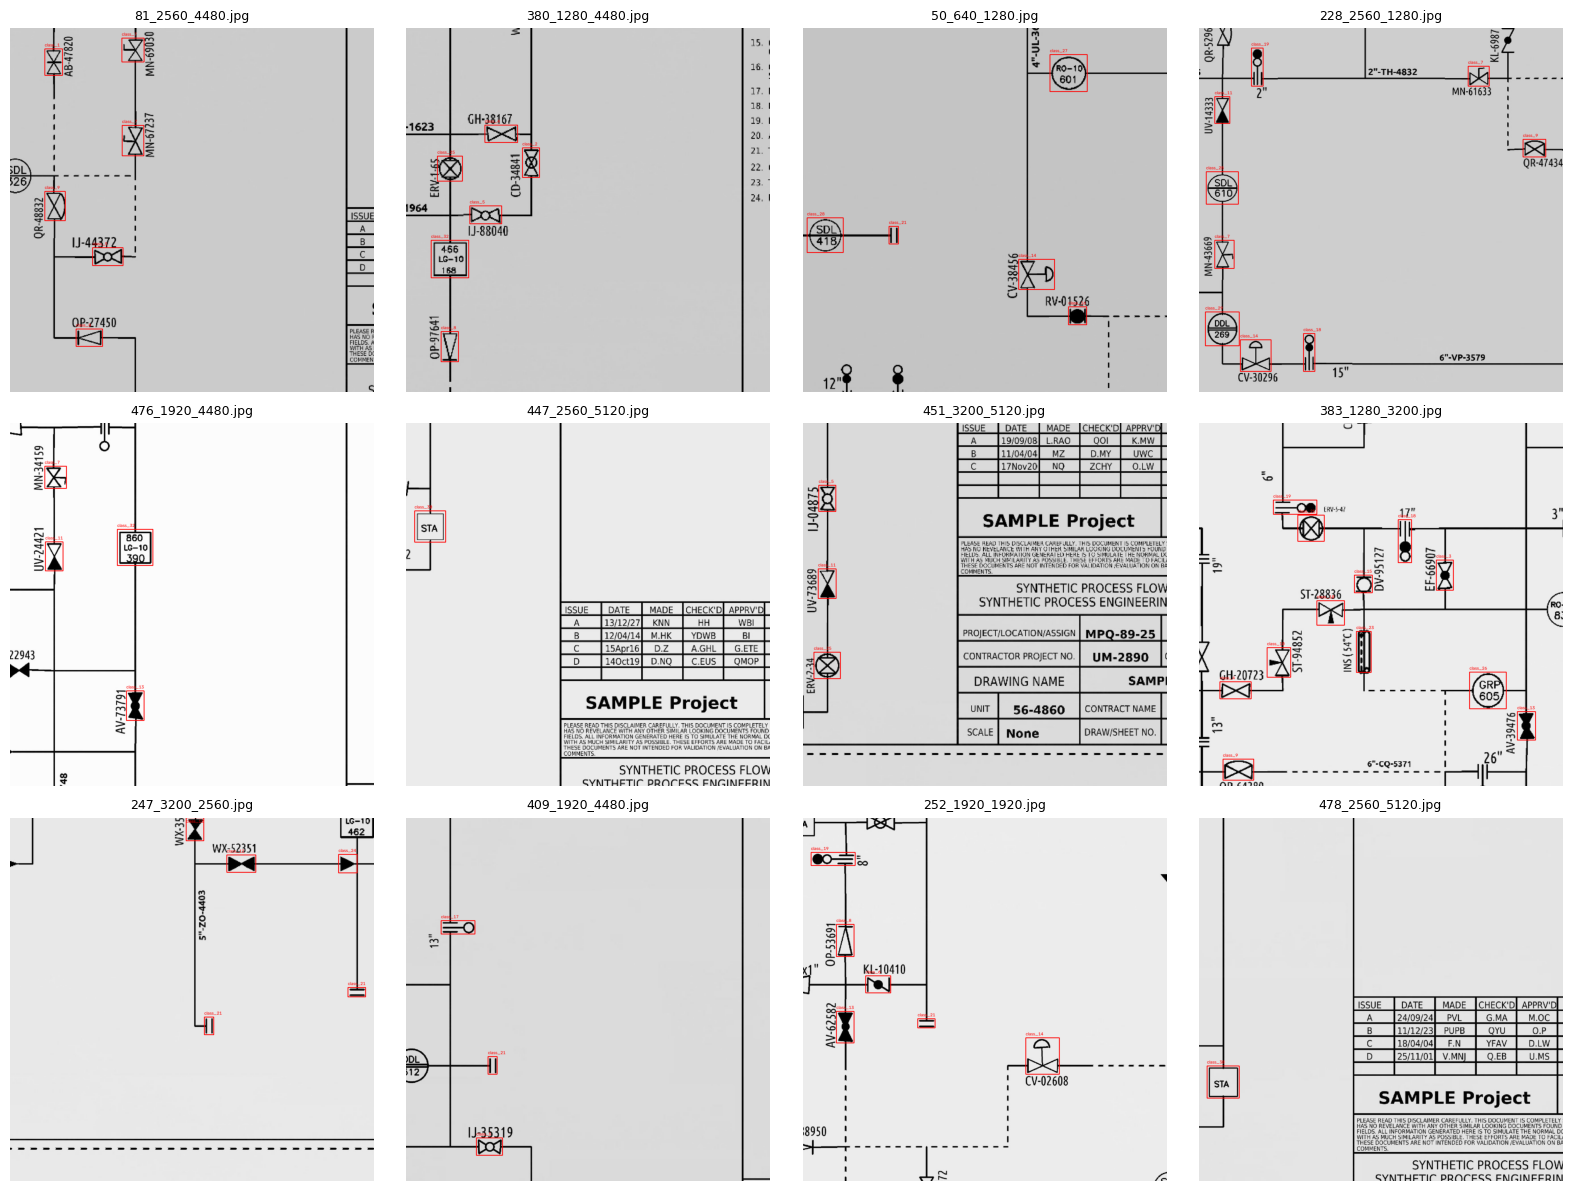

In [32]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, image_name in zip(axes.flat, development_subset):
    image = load_image_rgb(image_path_from_name(image_name))
    ann_df = load_yolo_annotations(label_path_from_name(image_name))
    pixel_df = yolo_to_pixel_boxes(ann_df, image_width=image.shape[1], image_height=image.shape[0])
    overlay = draw_boxes(image, pixel_df, class_name_map=CLASS_NAME_MAP)
    ax.imshow(overlay)
    ax.set_title(image_name, fontsize=9)
    ax.axis("off")

plt.tight_layout()


## Working Notes

Record findings here after running the cells above.

- Confirmed tile dimensions: (1280, 1280, 3)
- Confirmed filename convention: 
- Split overlap result:
- Most frequent class IDs: 21
- Candidate development subset notes:
